In [1]:
import numpy as np
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Initialize SHAP JavaScript for notebook rendering
shap.initjs()

print("Libraries loaded ✅")

c:\Users\rudre\OneDrive\Desktop\risksense-ai\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded ✅


In [2]:
# Load everything saved from previous notebooks
model         = joblib.load('../models/best_model.pkl')
scaler        = joblib.load('../models/scaler.pkl')
feature_names = joblib.load('../models/feature_names.pkl')

X_test  = np.load('../models/X_test_scaled.npy')
y_test  = np.load('../models/y_test.npy')

# Convert to DataFrame for SHAP — needs feature names
X_test_df = pd.DataFrame(X_test, columns=feature_names)

print(f"Model loaded: {type(model).__name__}")
print(f"Test samples: {X_test_df.shape[0]:,}")
print(f"Features: {feature_names}")

Model loaded: RandomForestClassifier
Test samples: 30,000
Features: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'TotalTimesLate', 'IncomeDebtBurden', 'UtilizationPerAccount', 'EverSeriouslyLate']


In [5]:
print("Creating SHAP explainer — please wait...")

explainer = shap.TreeExplainer(model)

sample_idx = np.random.choice(len(X_test_df), 2000, replace=False)
X_sample   = X_test_df.iloc[sample_idx]
y_sample   = y_test[sample_idx]

shap_values = explainer.shap_values(X_sample)

# Fix: Random Forest returns 3D array (n_samples, n_features, n_classes)
# Check the shape and extract correctly
print(f"Raw SHAP values type: {type(shap_values)}")

if isinstance(shap_values, list):
    # Old SHAP format — list of arrays, index [1] = default class
    shap_vals_default = shap_values[1]
    print("Format: list — using index [1]")
elif len(shap_values.shape) == 3:
    # New SHAP format — 3D array (samples, features, classes)
    shap_vals_default = shap_values[:, :, 1]
    print("Format: 3D array — using [:,:,1]")
else:
    shap_vals_default = shap_values
    print("Format: 2D array — using directly")

print(f"SHAP values shape: {shap_vals_default.shape}")
print(f"X_sample shape:    {X_sample.shape}")
print(f"Shapes match: {shap_vals_default.shape == X_sample.shape} ✅")

Creating SHAP explainer — please wait...
Raw SHAP values type: <class 'numpy.ndarray'>
Format: 3D array — using [:,:,1]
SHAP values shape: (2000, 14)
X_sample shape:    (2000, 14)
Shapes match: True ✅


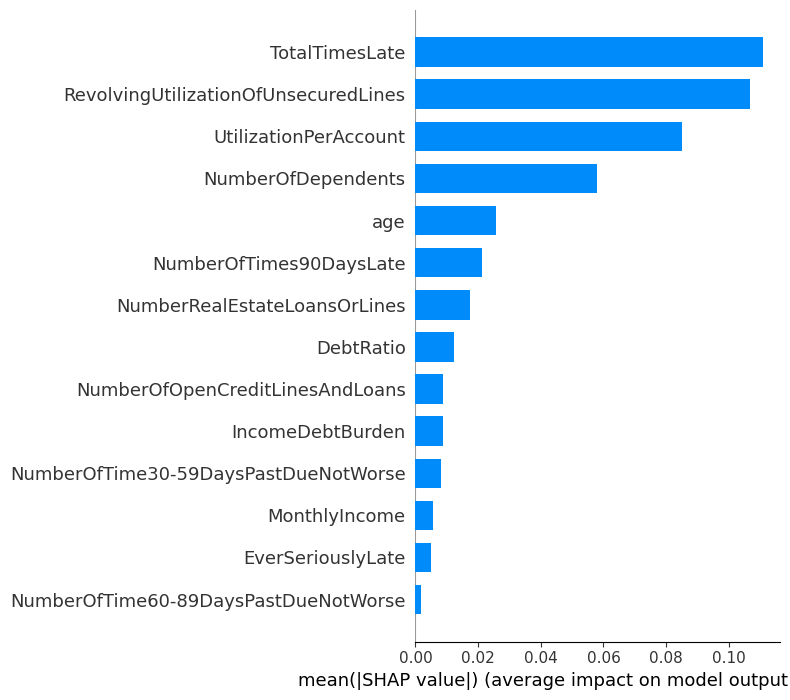

In [6]:
# This is better than model.feature_importances_
# SHAP shows DIRECTION of impact, not just magnitude

shap.summary_plot(
    shap_vals_default,
    X_sample,
    feature_names=feature_names,
    plot_type="bar",
    show=True
)

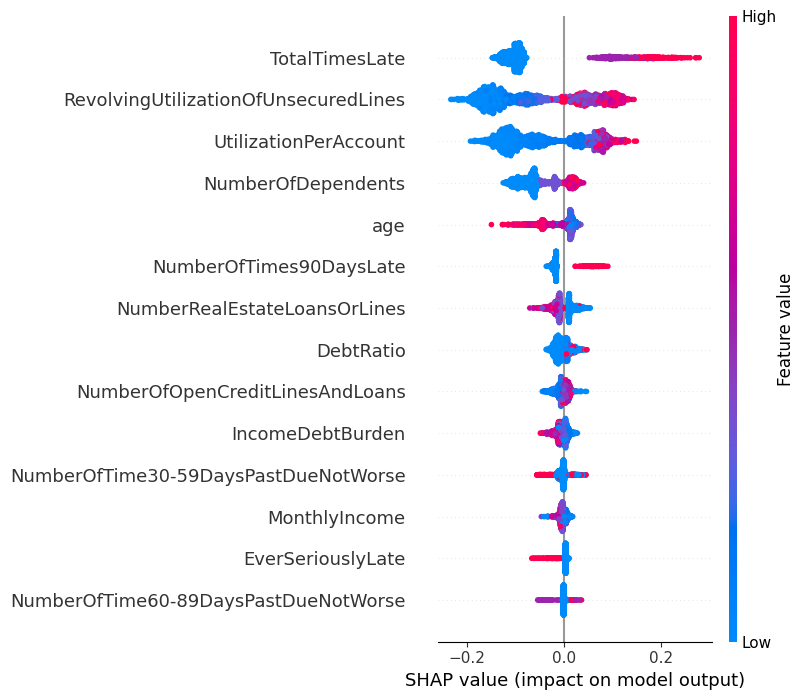

In [7]:
# The most informative SHAP plot
# Each dot = one applicant
# Color = feature value (red=high, blue=low)
# X position = impact on default prediction

shap.summary_plot(
    shap_vals_default,
    X_sample,
    feature_names=feature_names,
    show=True
)

Explaining applicant #20
Actual: DEFAULT
Predicted: DEFAULT
Default Probability: 63.3%

Applicant Details:
age                                     1.526154
MonthlyIncome                          -0.120401
DebtRatio                              -0.034046
TotalTimesLate                          0.313207
RevolvingUtilizationOfUnsecuredLines   -0.650204
Name: 26570, dtype: float64


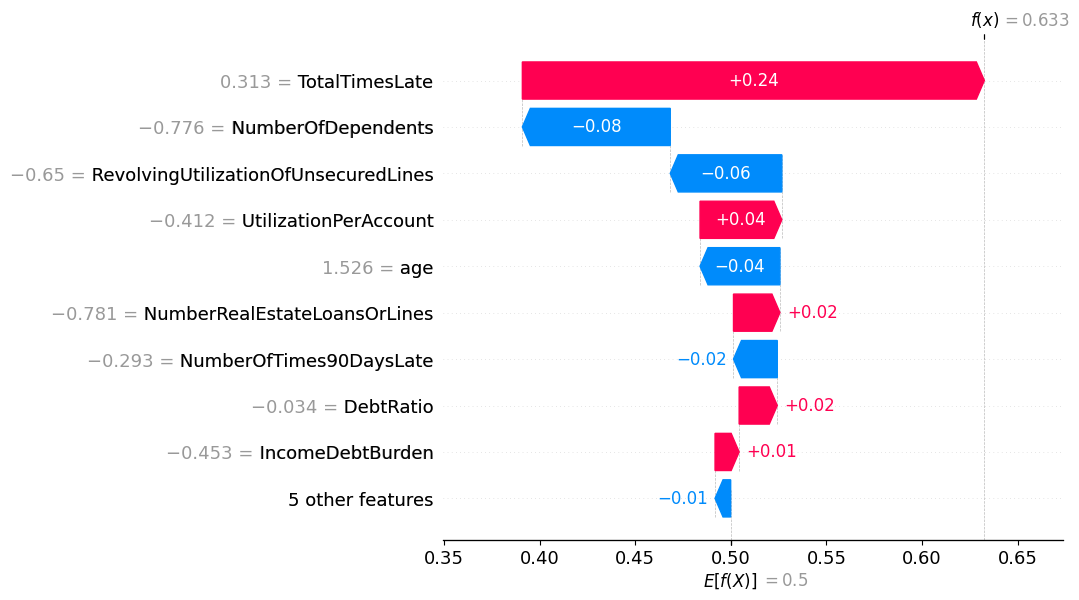

In [8]:
# Pick one defaulter and explain WHY the model flagged them
# This is what makes your app powerful

# Find a correctly predicted defaulter
predictions = model.predict(X_sample)
correct_defaulters = np.where((predictions == 1) & (y_sample == 1))[0]

if len(correct_defaulters) > 0:
    idx = correct_defaulters[0]
    print(f"Explaining applicant #{idx}")
    print(f"Actual: {'DEFAULT' if y_sample[idx]==1 else 'NO DEFAULT'}")
    print(f"Predicted: {'DEFAULT' if predictions[idx]==1 else 'NO DEFAULT'}")
    print(f"Default Probability: {model.predict_proba(X_sample.iloc[[idx]])[0][1]*100:.1f}%")
    print(f"\nApplicant Details:")
    print(X_sample.iloc[idx][['age', 'MonthlyIncome', 
                               'DebtRatio', 'TotalTimesLate',
                               'RevolvingUtilizationOfUnsecuredLines']])
    
    # Waterfall plot — shows each feature's contribution
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_vals_default[idx],
            base_values=explainer.expected_value[1],
            data=X_sample.iloc[idx].values,
            feature_names=feature_names
        )
    )

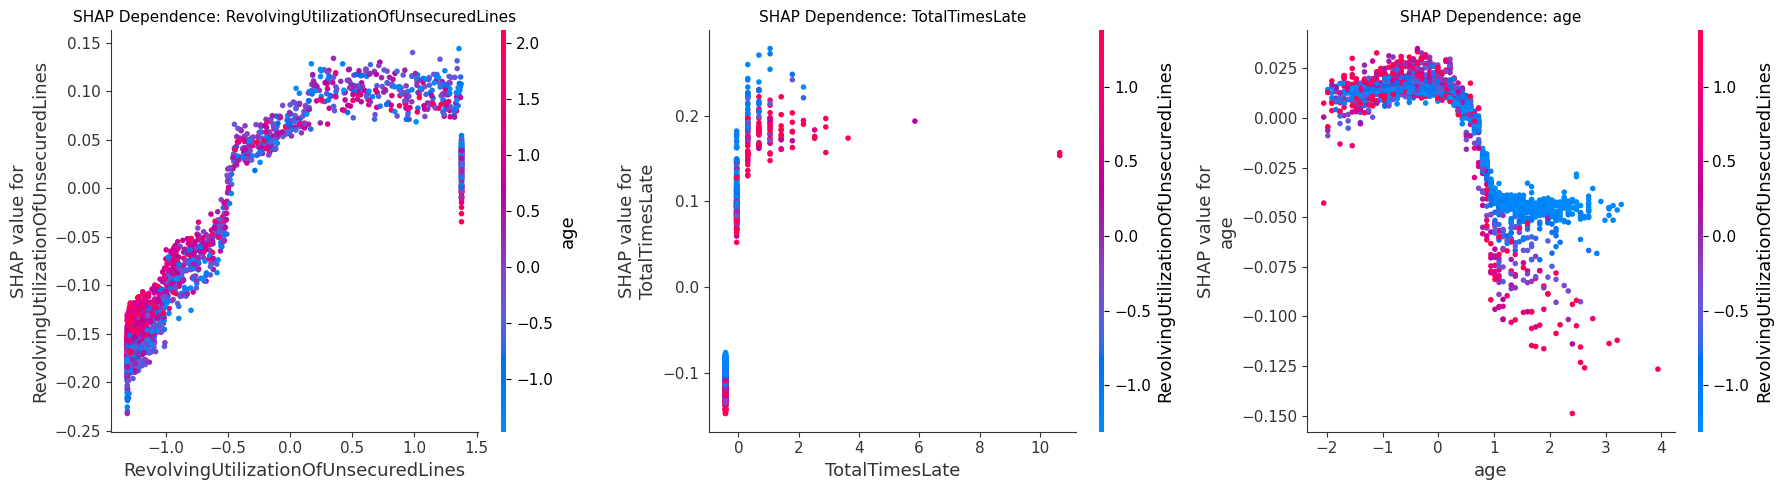

Saved: shap_dependence.png ✅


In [9]:
# Shows how each top feature affects default risk
# Reveals non-linear relationships your model learned

top_features = ['RevolvingUtilizationOfUnsecuredLines', 
                'TotalTimesLate', 
                'age']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feat in enumerate(top_features):
    shap.dependence_plot(
        feat,
        shap_vals_default,
        X_sample,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f'SHAP Dependence: {feat}', fontsize=11)

plt.tight_layout()
plt.savefig('../models/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_dependence.png ✅")

In [10]:
# Save explainer so the Streamlit app can generate
# real-time SHAP explanations for any new applicant

joblib.dump(explainer, '../models/shap_explainer.pkl')

print("Saved:")
print("  ✅ shap_explainer.pkl")
print("\n📊 SHAP Analysis Complete")
print("\nKey Insights from SHAP:")
print("→ RevolvingUtilization is the #1 driver of default risk")
print("→ More late payments = significantly higher risk")  
print("→ Older applicants tend to have lower default risk")
print("→ Your engineered TotalTimesLate feature is highly impactful")
print("\n🚀 Ready to build the Streamlit App")

Saved:
  ✅ shap_explainer.pkl

📊 SHAP Analysis Complete

Key Insights from SHAP:
→ RevolvingUtilization is the #1 driver of default risk
→ More late payments = significantly higher risk
→ Older applicants tend to have lower default risk
→ Your engineered TotalTimesLate feature is highly impactful

🚀 Ready to build the Streamlit App
